# Campaign Best Model Samples

Automatically selects the latest active NodeField campaign, finds the best completed trial so far, reloads its checkpoint, and samples graphs for inspection.

In [13]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

from IPython.display import display
import pandas as pd

from conditional_node_field_graph_generator.notebooks import configure_notebook
globals().update(configure_notebook(require_nsppk=True, print_torch=True))

from conditional_node_field_graph_generator.extensions.demo import (
    collect_campaign_trial_results,
    load_campaign_trial_generator,
    select_best_campaign_trial,
)
from conditional_node_field_graph_generator.extensions.demo.visualization import (
    infer_display_mode,
    plot_networkx_graphs,
    show_molecules,
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
PyTorch version: 2.12.0+cpu
CUDA available: False


In [14]:
CAMPAIGN_STATE_PATH = None  # keep None to auto-select the latest active campaign
DEVICE = "cpu"

In [15]:
ranking = collect_campaign_trial_results(
    repo_root=REPO_ROOT,
    campaign_state_path=CAMPAIGN_STATE_PATH,
)
selection = select_best_campaign_trial(
    repo_root=REPO_ROOT,
    campaign_state_path=CAMPAIGN_STATE_PATH,
)

print(f"Campaign: {selection.domain}/{selection.prefix}")
print(f"Best run: {selection.run_dir}")
print(f"Best trial: {selection.trial_dir.name}")
print(f"Checkpoint: {selection.checkpoint_path}")
display(ranking.head(20))


Campaign: artificial_graphs/artificial_graphs_large
Best run: /run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/NodeField/artifact/artificial_graphs/artificial_graphs_large_20260627_043826_b6b154
Best trial: trial_001
Checkpoint: /run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/NodeField/artifact/artificial_graphs/artificial_graphs_large_20260627_043826_b6b154/trials/trial_001/trials/trial_001/checkpoints/ConditionalNodeFieldGenerator_07da2bbb59144849946fcb07ff665d80/best-030-392.3950.ckpt


,average_num_violations,campaign_trial_id,feasible_rate,loss_pdf_path,median_num_violations,results_csv_path,trial_id,domain,prefix,run_dir,run_name,trial_dir,trial_name,metrics_path,config_path,checkpoint_path,campaign_state_path,campaign_status
0,65.250000,1,0.0,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,57.5,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,1,artificial_graphs,artificial_graphs_large,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,artificial_graphs_large_20260627_043826_b6b154,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,trial_001,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,running
1,121.625000,1,0.0,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,117.5,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,1,artificial_graphs,artificial_graphs_large,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,artificial_graphs_large_20260627_213846_764173,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,trial_001,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,running
2,157.812500,1,0.0,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,148.0,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,1,artificial_graphs,artificial_graphs_large,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,artificial_graphs_large_20260628_053951_a7340e,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,trial_001,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,running
3,178.437500,1,0.0,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,146.5,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,1,artificial_graphs,artificial_graphs_large,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,artificial_graphs_large_20260628_033936_8bcfdf,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,trial_001,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,running
4,209.125000,1,0.0,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,208.5,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,1,artificial_graphs,artificial_graphs_large,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,artificial_graphs_large_20260626_173806_9fb463,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,trial_001,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,running
5,223.437500,1,0.0,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,142.0,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,1,artificial_graphs,artificial_graphs_large,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,artificial_graphs_large_20260627_233905_416711,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,trial_001,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,running
6,229.562500,1,0.0,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,166.5,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,1,artificial_graphs,artificial_graphs_large,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,artificial_graphs_large_20260628_013922_a05d34,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,trial_001,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,running
7,302.250000,1,0.

In [16]:
graph_generator = load_campaign_trial_generator(
    selection,
    notebook_context=globals(),
    device=DEVICE,
)

print(f"Loaded checkpoint: {selection.checkpoint_path}")
print("is_fitted_ =", getattr(graph_generator, "is_fitted_", None))


Fitting graph vectorizer on 1000 graphs
Finished fitting graph vectorizer on 1000 graphs in 0m 0.0s
Fitting node graph vectorizer on 1000 graphs
Finished fitting node graph vectorizer on 1000 graphs in 0m 0.0s
Encoding node embeddings for 1000 graphs
Finished encoding node embeddings for 1000 graphs in 0m 9.8s
Encoding graph embeddings for 1000 graphs
Finished encoding graph embeddings for 1000 graphs in 0m 11.3s
Fitting embedding SVDs
Stacking raw node embeddings for SVD.
Stacked node embedding matrix: shape=(39000, 2048), sparse=True, nnz=7895809, density=0.098856.
Prepared graph embedding matrix: shape=(1000, 2048), sparse=True, nnz=1025172, density=0.500572.
Sampled node embedding SVD fit rows: 39000 -> 10000.
Fitting node embedding SVD on shape=(10000, 2048), sparse=True, nnz=2020415, density=0.098653 to 64 dimensions.
Fitted node embedding SVD: 2048 -> 64.
Fitting graph embedding SVD on shape=(1000, 2048), sparse=True, nnz=1025172, density=0.500572 to 128 dimensions.
Fitted graph

In [17]:
N_SAMPLES = 2
FEASIBILITY_EFFORT = 1
FEASIBILITY_FILTER = "none"  # "none", "fallback", or "strict"

MAX_DISPLAY_GRAPHS = 16
N_COLS = 4

In [18]:
generated_graphs = list(
    graph_generator.sample(
        n_samples=N_SAMPLES,
        feasibility_effort=FEASIBILITY_EFFORT,
        feasibility_filter=FEASIBILITY_FILTER,
    )
)

violation_counts = [
    float(value)
    for value in graph_generator.feasibility_estimator.number_of_violations(generated_graphs)
]
sample_summary = {
    "n_samples": N_SAMPLES,
    "returned_samples": len(generated_graphs),
    "feasibility_effort": FEASIBILITY_EFFORT,
    "feasibility_filter": FEASIBILITY_FILTER,
    "average_num_violations": (
        sum(violation_counts) / len(violation_counts) if violation_counts else float("nan")
    ),
    "feasible_rate": (
        sum(value == 0 for value in violation_counts) / len(violation_counts)
        if violation_counts
        else float("nan")
    ),
}

display(pd.DataFrame([sample_summary]))


Sampling 2 ILP graphs
Feasibility effort failed; retrying lower-effort fallbacks (effort=1, error=Process-based parallel adjacency decode exceeded 30.0s.).
Feasibility effort returned no graphs; retrying same sampled conditioning at lower effort(s) (0,).


,n_samples,returned_samples,feasibility_effort,feasibility_filter,average_num_violations,feasible_rate
0,2,2,1,none,353.5,0.0


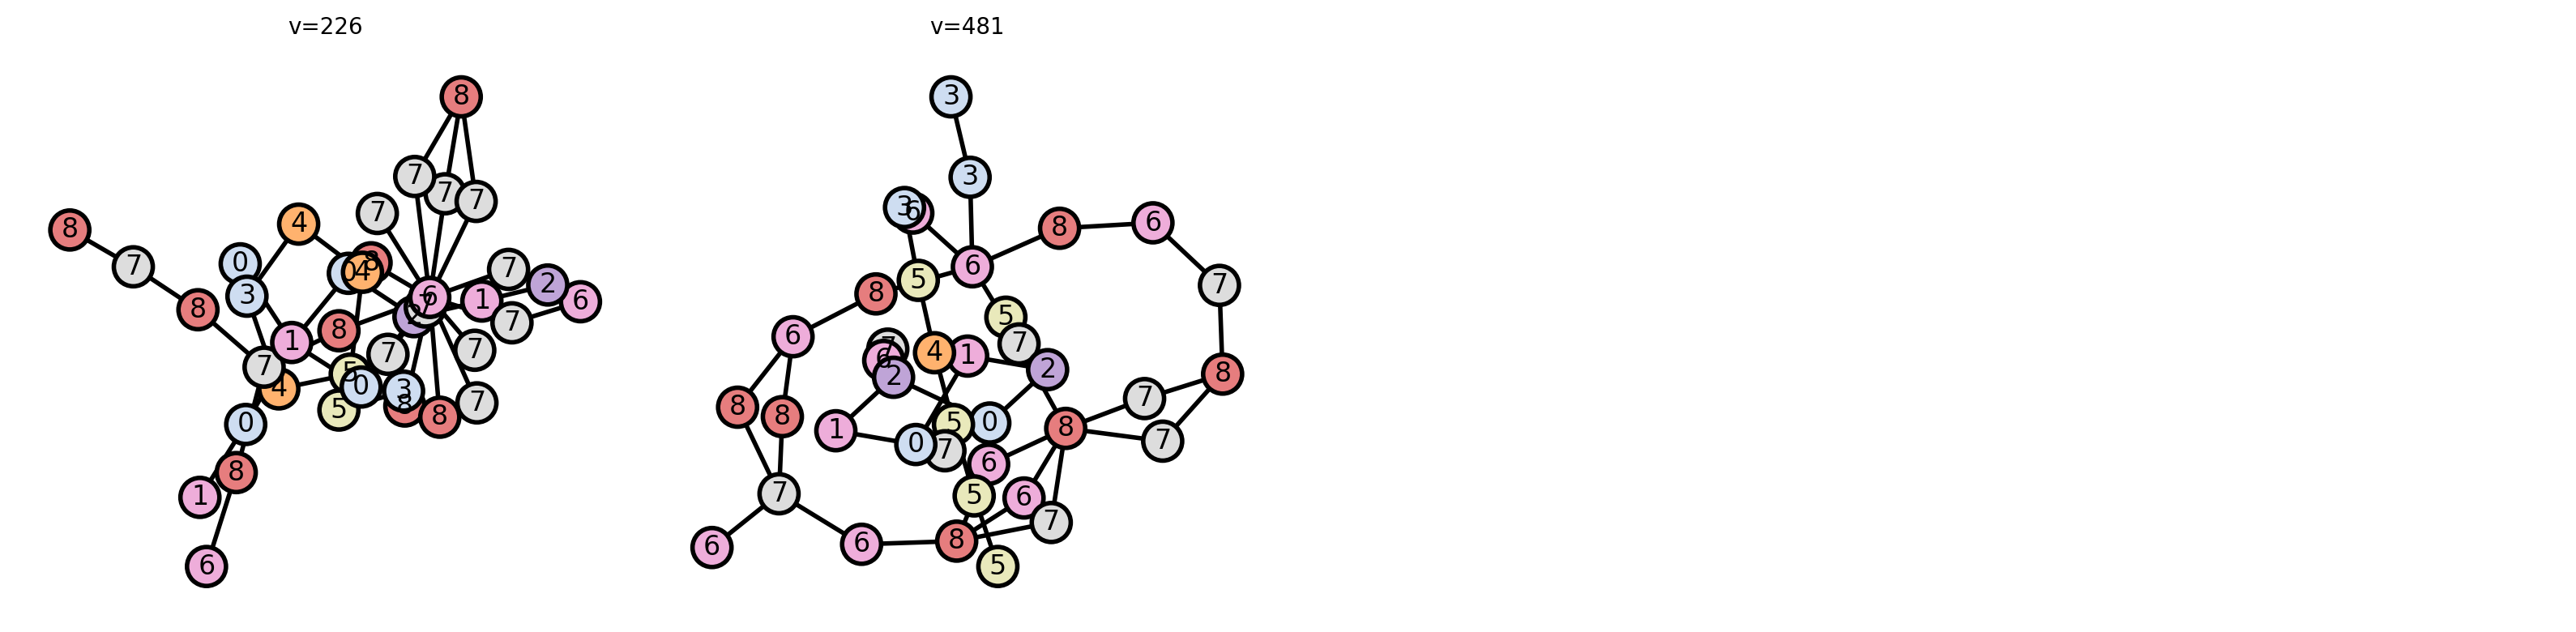

In [19]:
graphs_to_show = generated_graphs[:MAX_DISPLAY_GRAPHS]
titles = [f"v={value:g}" for value in violation_counts[:len(graphs_to_show)]]
display_mode = infer_display_mode(graphs_to_show)

if display_mode == "molecule":
    show_molecules(
        graphs_to_show,
        n=len(graphs_to_show),
        title="Best campaign model samples",
        legends=titles,
        n_graphs_per_line=N_COLS,
    )
else:
    plot_networkx_graphs(
        graphs_to_show,
        n_cols=N_COLS,
        mode=display_mode,
        titles=titles,
    )
